In [ ]:
#checking for all the files
import os

# List files in current Colab directory
os.listdir("/content")

['.config', 'Student_performance_data _.csv', 'sample_data']

In [ ]:
import pandas as pd

# Use the exact file name
df = pd.read_csv("/content/Student_performance_data _.csv")

# Check first 5 rows
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [8]:
import pandas as pd

# Load dataset first
df = pd.read_csv("/content/Student_performance_data _.csv")

# Then drop column
df = df.drop("StudentID", axis=1)

In [9]:
X = df.drop("GradeClass", axis=1)  # Features
y = df["GradeClass"]               # Target

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [13]:
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [14]:
#building the ann
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))

# Second hidden layer
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

# Output layer (5 classes)
model.add(Dense(5, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
#training the model
history = model.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3549 - loss: 1.4790 - val_accuracy: 0.5170 - val_loss: 1.3171
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5549 - loss: 1.2382 - val_accuracy: 0.5248 - val_loss: 1.1642
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5817 - loss: 1.0990 - val_accuracy: 0.5692 - val_loss: 1.0654
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6137 - loss: 1.0164 - val_accuracy: 0.6084 - val_loss: 1.0011
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6346 - loss: 0.9585 - val_accuracy: 0.6345 - val_loss: 0.9643
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6497 - loss: 0.9266 - val_accuracy: 0.6501 - val_loss: 0.9511
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6575 - loss: 0.9349 - val_accuracy: 0.6736 - val_loss: 0.9353
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6627 - loss: 0.8944 - val_accuracy: 0.6867 - val_loss:

In [16]:
# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels
y_pred = y_pred_prob.argmax(axis=1)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [18]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.8079
Precision: 0.7680
Recall: 0.8079
F1-Score: 0.7871


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[  0  15   3   2   2]
 [  0  28  16   1   4]
 [  0   3  67  10   5]
 [  0   2   5  63  16]
 [  0   1   0   7 229]]


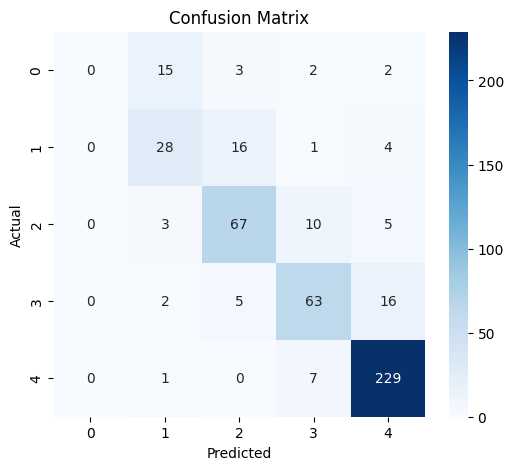

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# 13. CAREER RECOMMENDATION FUNCTION

def recommend_career(grade):
    if grade == 4:
        return "Engineering / Data Science / AI"
    elif grade == 3:
        return "IT / Business / Management"
    elif grade == 2:
        return "Diploma / Technical Skills"
    elif grade == 1:
        return "Vocational Training / Basic Jobs"
    else:
        return "Skill Development Programs"



In [21]:
for i in range(5):  # show first 5 students
    grade = model.predict(X_test[i].reshape(1, -1)).argmax()

    career = recommend_career(grade)

    print(f"Student {i+1}: Predicted Grade = {grade}")
    print(f"Recommended Career: {career}")
    print("-" * 40)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Student 1: Predicted Grade = 4
Recommended Career: Engineering / Data Science / AI
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Student 2: Predicted Grade = 2
Recommended Career: Diploma / Technical Skills
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Student 3: Predicted Grade = 4
Recommended Career: Engineering / Data Science / AI
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Student 4: Predicted Grade = 1
Recommended Career: Vocational Training / Basic Jobs
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Student 5: Predicted Grade = 4
Recommended Career: Engineering / Data Science / AI
----------------------------------------
